In [66]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import f1_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [47]:
df = pd.read_csv("mxmh_cleaned.csv")

In [48]:
df['genre_list'] = df['genre_list'].apply(ast.literal_eval)
df['genre_list'].head()

,genre_list
0,"[Hiphop Rap, Kpop, Latin, Pop]"
1,"[Jazz, Rock Metal]"
2,"[Edm Lofi Vgm, Kpop]"
3,"[Jazz, Latin]"
4,"[Hiphop Rap, Kpop, Randb Gospel]"


In [57]:
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(df["genre_list"])
X = df.drop(columns=["genre_list"]).values

print("Labels:", mlb.classes_)
print("Y shape:", Y.shape)
print("X shape:", X.shape)

X = df.drop(columns=["genre_list"]).fillna(0).values
print("NaNs in X:", np.isnan(X).sum())
print("NaNs in Y:", np.isnan(Y).sum())

Labels: ['Classical' 'Country Folk' 'Edm Lofi Vgm' 'Hiphop Rap' 'Jazz' 'Kpop'
 'Latin' 'Pop' 'Randb Gospel' 'Rock Metal']
Y shape: (736, 10)
X shape: (736, 19)
NaNs in X: 0
NaNs in Y: 0


In [58]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [59]:
k = Y_train.shape[1]

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(k, activation="sigmoid")
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy"
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train, Y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.7026 - val_loss: 0.6378
Epoch 2/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.6379 - val_loss: 0.5770
Epoch 3/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.5915 - val_loss: 0.5134
Epoch 4/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.5253 - val_loss: 0.4544
Epoch 5/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.4759 - val_loss: 0.4132
Epoch 6/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.4442 - val_loss: 0.3882
Epoch 7/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.4351 - val_loss: 0.3705
Epoch 8/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.4046 - val_loss: 0.3555
Epoch 9/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.4076 - val_loss: 0.3432
Epoch 10/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.3745 - val_loss: 0.3299
Epoch 11/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3605 - val_loss: 0.3189
Epoch 12/200
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

In [88]:
probs = model.predict(X_test)
Y_pred = (probs >= 0.4).astype(int)

print("Micro F1:", f1_score(Y_test, Y_pred, average="micro"))
print("Macro F1:", f1_score(Y_test, Y_pred, average="macro"))
print("Weighted F1:", f1_score(Y_test, Y_pred, average="weighted"))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Micro F1: 0.9259259259259259
Macro F1: 0.8603779744268621
Weighted F1: 0.9225118673988137


In [89]:
per_genre_f1 = f1_score(Y_test, Y_pred, average=None)
for name, score in sorted(zip(mlb.classes_, per_genre_f1), key=lambda x: x[1]):
    print(f"{name:15s} F1 = {score:.2f}")

Jazz            F1 = 0.57
Latin           F1 = 0.67
Kpop            F1 = 0.83
Randb Gospel    F1 = 0.87
Classical       F1 = 0.91
Country Folk    F1 = 0.92
Hiphop Rap      F1 = 0.94
Edm Lofi Vgm    F1 = 0.96
Pop             F1 = 0.96
Rock Metal      F1 = 0.98


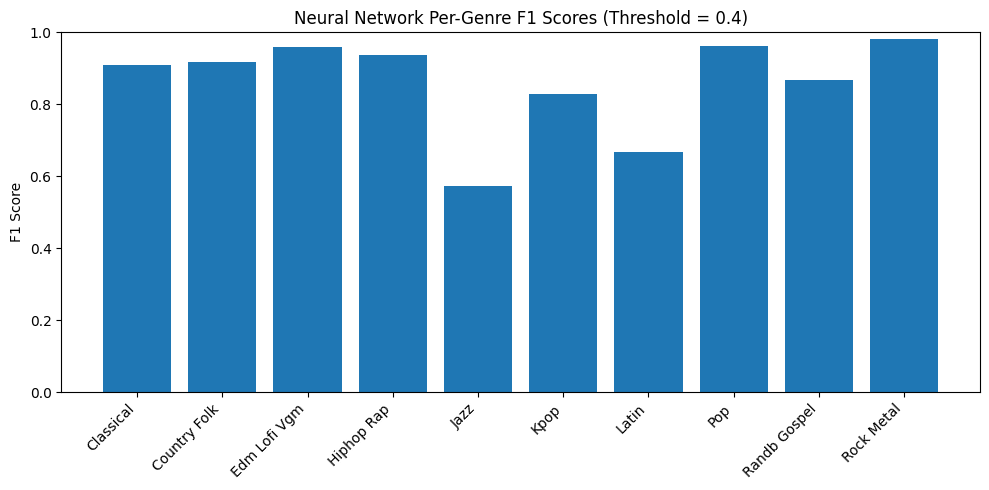

In [90]:
per_genre_f1 = f1_score(Y_test, Y_pred, average=None)

plt.figure(figsize=(10,5))
plt.bar(mlb.classes_, per_genre_f1)
plt.xticks(rotation=45, ha="right")
plt.ylabel("F1 Score")
plt.title("Neural Network Per-Genre F1 Scores (Threshold = 0.4)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

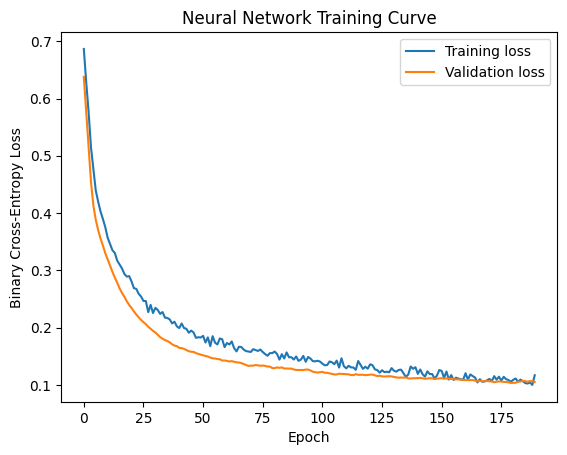

In [91]:
plt.figure()
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Neural Network Training Curve")
plt.legend()
plt.show()